**Library Imports**

In [1]:
# pandas  — data loading, cleaning, and manipulation
# numpy   — numerical operations and array handling
# matplotlib & seaborn — data visualisation
# sklearn — machine learning models and evaluation metrics

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, roc_curve, auc)

print("All libraries imported successfully!")

All libraries imported successfully!


Importing all required libraries for data processing, visualization, and machine learning.

**Cell 1 — Data Loading**

In [24]:
# Load the dataset from CSV file
df = pd.read_csv("Student Mental health.csv")

# Drop Timestamp — it is a survey submission time,
# not a meaningful feature for predicting depression
df.drop(columns=['Timestamp'], inplace=True)

# --- Fix inconsistent text entries ---
# .str.lower() converts all text to lowercase (e.g. 'Year 1' → 'year 1')
# .str.strip() removes any leading or trailing spaces
df['Your current year of Study'] = df['Your current year of Study'].str.lower().str.strip()
df['What is your CGPA?']         = df['What is your CGPA?'].str.strip()
df['What is your course?']       = df['What is your course?'].str.lower().str.strip()

# --- Merge near-duplicate course names into one clean label ---
# The survey had free-text course entry, so students typed the
# same course in different ways (e.g. 'engin', 'engine', 'engineering')
# This mapping standardises them into a single consistent value
course_map = {
    'engin'            : 'engineering',
    'engine'           : 'engineering',
    'kirkhs'           : 'irkhs',
    'laws'             : 'law',
    'koe'              : 'koe',
    'fiqh fatwa'       : 'fiqh',
    'pendidikan islam' : 'pendidikan islam',
    'islamic education': 'islamic education',
    'human sciences'   : 'human sciences',
    'diploma tesl'     : 'tesl',
    'diploma nursing'  : 'nursing',
}
df['What is your course?'] = df['What is your course?'].replace(course_map)

# --- Handle missing values in Age ---
# Only 1 missing value found — replaced with mean age
# to avoid losing a data row in a small dataset (101 rows)
df['Age'] = df['Age'].fillna(df['Age'].mean())

# --- Rename columns to short, clean names for easier coding ---
df.columns = ['Gender', 'Age', 'Course', 'Year', 'CGPA',
              'Marital_Status', 'Depression', 'Anxiety',
              'Panic_Attack', 'Specialist_Treatment']

# --- Verification ---
print("Cleaned! Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("\nUnique courses after cleaning:", df['Course'].nunique())
print(df['Course'].value_counts())

df.head()

Cleaned! Shape: (101, 10)
Missing values: 0

Unique courses after cleaning: 35
Course
engineering                20
bcs                        18
bit                        10
koe                         6
biomedical science          4
psychology                  3
pendidikan islam            3
benl                        3
irkhs                       3
law                         3
islamic education           2
fiqh                        2
nursing                     2
enm                         1
marine science              1
kenms                       1
accounting                  1
human resources             1
mathemathics                1
taasl                       1
usuluddin                   1
business administration     1
banking studies             1
cts                         1
econs                       1
ala                         1
it                          1
malcom                      1
mhsc                        1
kop                         1
human sciences

,Gender,Age,Course,Year,CGPA,Marital_Status,Depression,Anxiety,Panic_Attack,Specialist_Treatment
0,Female,18.0,engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,Male,21.0,islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,Male,19.0,bit,year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,Female,22.0,law,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,Male,23.0,mathemathics,year 4,3.00 - 3.49,No,No,No,No,No


Loading the dataset, removing irrelevant columns, fixing inconsistent text entries,
merging duplicate course names, and handling missing Age values using mean imputation.

The dataset consists of student-related features such as age, gender, academic information, and mental health indicators. Initial inspection shows that the dataset contains both categorical and numerical variables. Some missing values are present, which need to be handled before model development.

Missing values in the dataset were handled using mean imputation for numerical variables. This ensures that the dataset remains complete without significantly altering the distribution of the data.

**Descriptive Statistics**

In [25]:
# This cell gives us a numerical summary of the dataset
# before we start building any models

# Numeric statistics — mean, std, min, max for Age
print("=== DESCRIPTIVE STATISTICS (Numeric) ===")
print(df.describe())
print()

# Frequency counts for all categorical columns
# This helps us understand the distribution of each variable
print("=== VALUE COUNTS FOR ALL CATEGORICAL COLUMNS ===")
for col in ['Gender', 'Year', 'CGPA', 'Marital_Status',
            'Depression', 'Anxiety', 'Panic_Attack', 'Specialist_Treatment']:
    print(f"\n{col}:")
    print(df[col].value_counts())

print()

# Summary of our target variable (Depression)
# Important to check class balance before modelling
print("=== DEPRESSION SUMMARY ===")
print("No Depression :", df[df['Depression']=='No'].shape[0], "students")
print("Has Depression:", df[df['Depression']=='Yes'].shape[0], "students")
print("Depression Rate:", round((df['Depression']=='Yes').mean()*100, 1), "%")
# Note: 34.7% is a moderate imbalance — we handle this
# using stratified splitting in the train/test split later

=== DESCRIPTIVE STATISTICS (Numeric) ===
              Age
count  101.000000
mean    20.530000
std      2.483767
min     18.000000
25%     18.000000
50%     19.000000
75%     23.000000
max     24.000000

=== VALUE COUNTS FOR ALL CATEGORICAL COLUMNS ===

Gender:
Gender
Female    75
Male      26
Name: count, dtype: int64

Year:
Year
year 1    43
year 2    26
year 3    24
year 4     8
Name: count, dtype: int64

CGPA:
CGPA
3.50 - 4.00    48
3.00 - 3.49    43
2.50 - 2.99     4
0 - 1.99        4
2.00 - 2.49     2
Name: count, dtype: int64

Marital_Status:
Marital_Status
No     85
Yes    16
Name: count, dtype: int64

Depression:
Depression
No     66
Yes    35
Name: count, dtype: int64

Anxiety:
Anxiety
No     67
Yes    34
Name: count, dtype: int64

Panic_Attack:
Panic_Attack
No     68
Yes    33
Name: count, dtype: int64

Specialist_Treatment:
Specialist_Treatment
No     95
Yes     6
Name: count, dtype: int64

=== DEPRESSION SUMMARY ===
No Depression : 66 students
Has Depression: 35 students
D

- Average student age is **20.5 years**, ranging from 18 to 24 — a typical university population
- **75 out of 101 students (74%) are Female** — the dataset is heavily female-dominated,
  which may influence results and should be noted as a limitation
- Most students are in **Year 1 (43 students)** and have a **CGPA of 3.50–4.00 (48 students)**
  indicating an academically strong sample
- **35 out of 101 students (34.7%) report Depression** — this is a significant proportion,
  highlighting the severity of mental health issues in university settings
- Only **6 students (5.9%) sought specialist treatment** despite 35 reporting depression —
  this large gap suggests students are not getting the professional help they need

**Plot 1 — Depression Distribution**

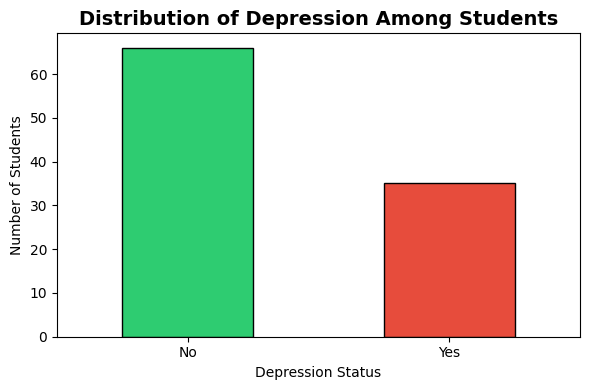

Plot 1 done!


In [26]:

# Shows how many students have depression vs do not
# This is our target variable — always visualise it first
# to understand class balance before modelling

plt.figure(figsize=(6,4))
df['Depression'].value_counts().plot(kind='bar',
    color=['#2ecc71','#e74c3c'], edgecolor='black')
plt.title('Distribution of Depression Among Students',
          fontsize=14, fontweight='bold')
plt.xlabel('Depression Status')
plt.ylabel('Number of Students')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('plot1_depression_distribution.png', dpi=150)
plt.show()
print("Plot 1 done!")

- **66 students (65.3%) do not have depression** and **35 students (34.7%) do**
- The class distribution is moderately imbalanced but not severely so
- This confirms we must use **stratified splitting** to ensure both train and test sets
  reflect this 65/35 ratio during model training

**Plot 2 — Gender vs Depression**

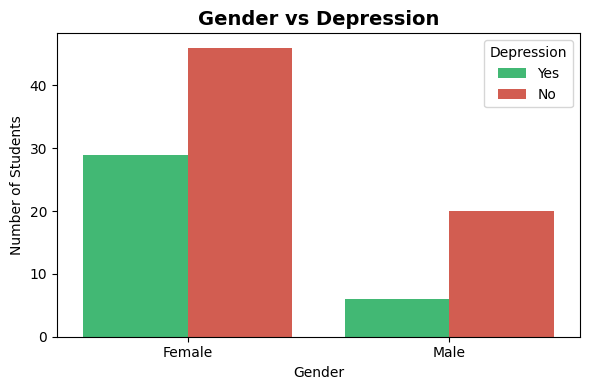

Plot 2 done!


In [27]:
# Investigates whether gender is associated with depression
# The dataset has 75 females and 26 males — checking if
# depression rate differs between the two groups

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Gender', hue='Depression',
              palette=['#2ecc71','#e74c3c'])
plt.title('Gender vs Depression', fontsize=14, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Number of Students')
plt.legend(title='Depression')
plt.tight_layout()
plt.savefig('plot2_gender_depression.png', dpi=150)
plt.show()
print("Plot 2 done!")

- Female students show a noticeably higher count of depression compared to male students
- However, since females make up 74% of the dataset, the higher count is partly
  due to larger representation rather than a higher rate
- This suggests **gender alone is not a strong standalone predictor** of depression
  but may contribute when combined with other features

**Plot 3 — Age Distribution**

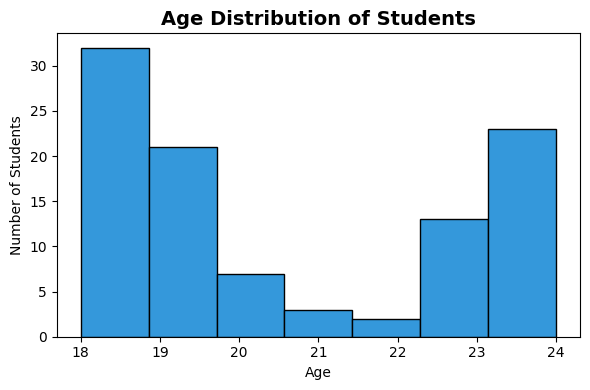

Plot 3 done!


In [28]:
# Shows the spread of student ages in the dataset
# Most students are between 18–24 years old
# Helps identify if age is concentrated or spread out

plt.figure(figsize=(6,4))
plt.hist(df['Age'], bins=7, color='#3498db', edgecolor='black')
plt.title('Age Distribution of Students', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Number of Students')
plt.tight_layout()
plt.savefig('plot3_age_distribution.png', dpi=150)
plt.show()
print("Plot 3 done!")

- The majority of students are aged **18 and 19 years**, showing a right-skewed distribution
- Very few students are aged 23 or 24, meaning older students are underrepresented
- Age is concentrated in a narrow range (18–24), which **limits its predictive power**
  as there is not enough variation for the model to learn strong age-based patterns

**Plot 4 — Anxiety vs Depression**

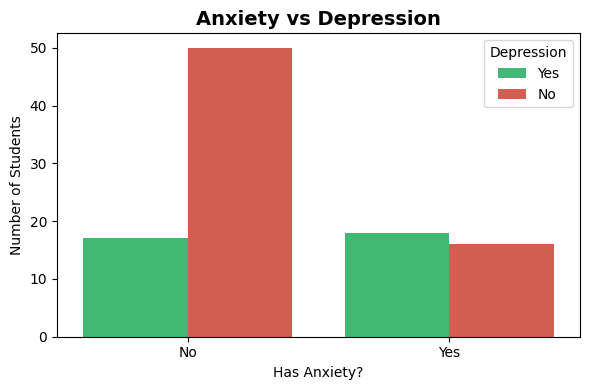

Plot 4 done!


In [29]:
# EDA Plot 4: Anxiety vs Depression
# Anxiety is expected to be strongly linked to depression
# This plot checks if students with anxiety are more likely
# to also have depression — a key relationship to verify

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Anxiety', hue='Depression',
              palette=['#2ecc71','#e74c3c'])
plt.title('Anxiety vs Depression', fontsize=14, fontweight='bold')
plt.xlabel('Has Anxiety?')
plt.ylabel('Number of Students')
plt.legend(title='Depression')
plt.tight_layout()
plt.savefig('plot4_anxiety_depression.png', dpi=150)
plt.show()
print("Plot 4 done!")

- Students who report anxiety are **significantly more likely** to also report depression
- This confirms a strong clinical relationship between the two conditions
- **Anxiety is expected to be one of the strongest predictors** in our machine learning models
- Students without anxiety are mostly depression-free, which further validates this relationship

**Plot 5 — CGPA vs Depression**

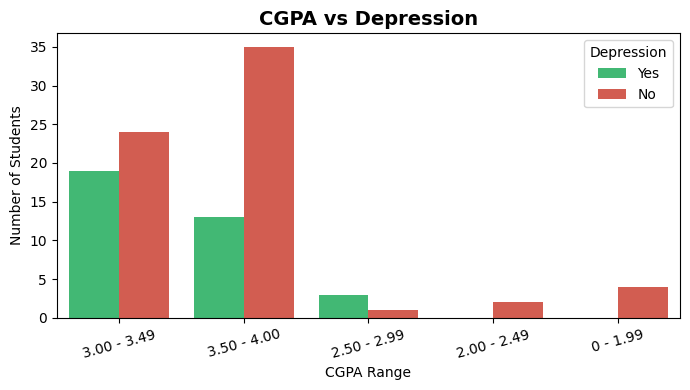

Plot 5 done!


In [30]:
# EDA Plot 5: CGPA vs Depression
# Investigates whether academic performance (CGPA) is linked
# to depression — lower CGPA students may be under more stress
# and therefore more likely to experience depression

plt.figure(figsize=(7,4))
sns.countplot(data=df, x='CGPA', hue='Depression',
              palette=['#2ecc71','#e74c3c'])
plt.title('CGPA vs Depression', fontsize=14, fontweight='bold')
plt.xlabel('CGPA Range')
plt.ylabel('Number of Students')
plt.xticks(rotation=15)
plt.legend(title='Depression')
plt.tight_layout()
plt.savefig('plot5_cgpa_depression.png', dpi=150)
plt.show()
print("Plot 5 done!")

- Depression cases appear across **all CGPA ranges**, not just low performers
- Students in the **3.00–3.49 and 3.50–4.00 CGPA range** show the highest depression counts
- This is surprising — high-achieving students appear equally or more affected,
  possibly due to **academic pressure and perfectionism**
- CGPA alone does not clearly separate depressed from non-depressed students,
  suggesting it is a **weak standalone predictor** but may still contribute in combination

**Plot 6 — Panic Attack vs Depression**

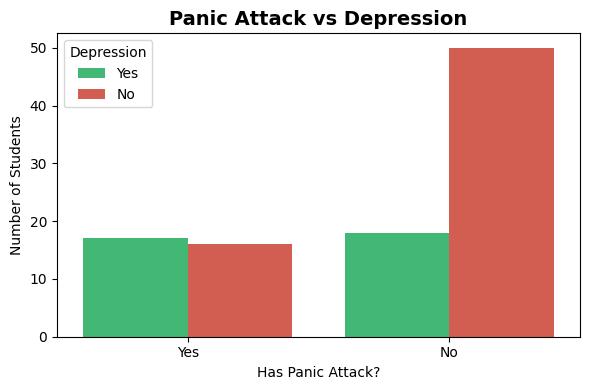

Plot 6 done!


In [31]:
# EDA Plot 6: Panic Attack vs Depression
# Panic attacks are a known symptom linked to depression
# This plot checks the overlap between the two conditions
# among students in the dataset

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Panic_Attack', hue='Depression',
              palette=['#2ecc71','#e74c3c'])
plt.title('Panic Attack vs Depression', fontsize=14, fontweight='bold')
plt.xlabel('Has Panic Attack?')
plt.ylabel('Number of Students')
plt.legend(title='Depression')
plt.tight_layout()
plt.savefig('plot6_panic_depression.png', dpi=150)
plt.show()
print("Plot 6 done!")

- Students who experience panic attacks show a **much higher rate of depression**
  compared to those who do not
- This confirms panic attacks and depression are strongly co-occurring conditions
- **Panic Attack is expected to be a significant predictor** in our models,
  alongside Anxiety — both are key mental health indicators

**Plot 7 — Scatter Plot (Age vs Depression)**

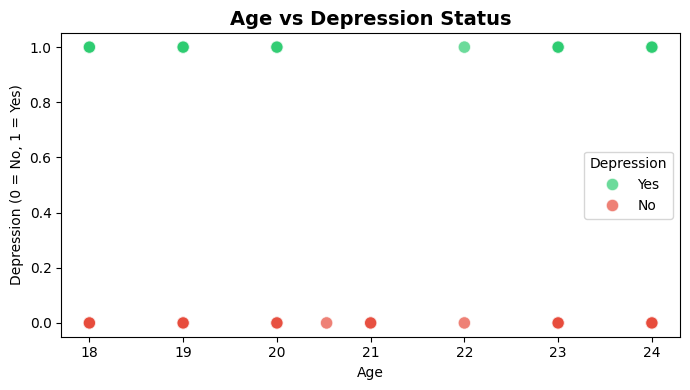

Scatter plot done!


In [32]:
# EDA Plot 7: Scatter Plot — Age vs Depression (encoded)
# Scatter plots show individual data points and their spread
# Depression is encoded as 0 (No) and 1 (Yes) on the Y axis
# so we can see if any age group clusters more at 1 (depressed)

df_scatter = df.copy()
# Encode Depression as 0/1 for the Y axis
df_scatter['Depression_num'] = (df_scatter['Depression'] == 'Yes').astype(int)

plt.figure(figsize=(7, 4))
sns.scatterplot(data=df_scatter, x='Age', y='Depression_num',
                hue='Depression', palette=['#2ecc71','#e74c3c'],
                alpha=0.7, s=80)
plt.title('Age vs Depression Status', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Depression (0 = No, 1 = Yes)')
plt.tight_layout()
plt.savefig('plot7_scatter_age_depression.png', dpi=150)
plt.show()
print("Scatter plot done!")

- Depressed students (shown in red at y=1) are spread across all age groups from 18 to 24
- There is no clear age group that is significantly more affected than others
- This confirms that **age alone is not a strong predictor of depression**
  in this dataset — depression affects students of all ages equally
- The scatter plot validates the need to use **multiple features together**
  rather than relying on any single variable for prediction

**Correlation Heatmap**

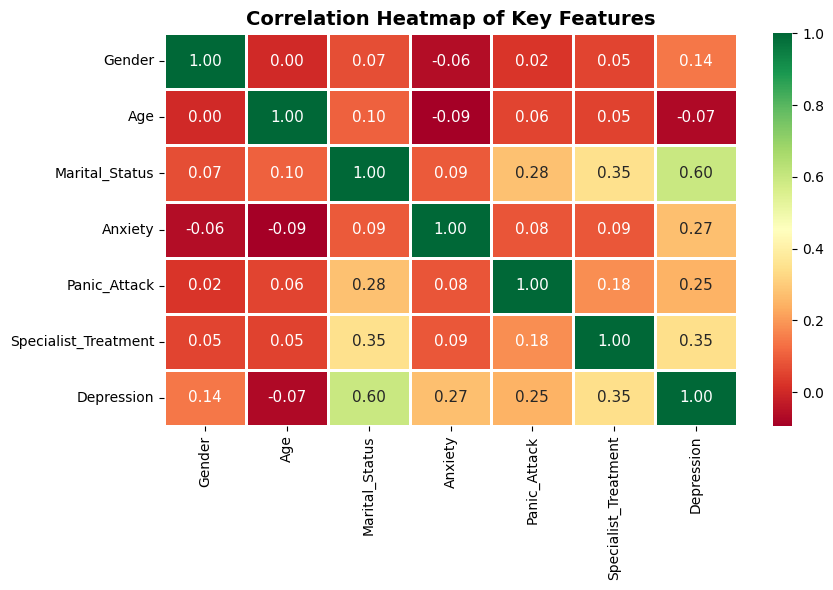

Clean heatmap saved!


In [33]:
# EDA Plot 11: Correlation Heatmap
# A heatmap shows how strongly each feature is correlated
# with every other feature — values close to +1 mean strong
# positive relationship, close to -1 means strong negative
# We only include key binary features, not Course/Year,
# because those need dummy encoding first

df_heat = df.copy()

# Encode Yes/No and Female/Male columns as 1/0
# so they can be used in a numeric correlation matrix
df_heat['Gender']               = (df_heat['Gender'] == 'Female').astype(int)
df_heat['Depression']           = (df_heat['Depression'] == 'Yes').astype(int)
df_heat['Anxiety']              = (df_heat['Anxiety'] == 'Yes').astype(int)
df_heat['Panic_Attack']         = (df_heat['Panic_Attack'] == 'Yes').astype(int)
df_heat['Marital_Status']       = (df_heat['Marital_Status'] == 'Yes').astype(int)
df_heat['Specialist_Treatment'] = (df_heat['Specialist_Treatment'] == 'Yes').astype(int)

# Select only the relevant numeric columns for the heatmap
df_heat = df_heat[['Gender', 'Age', 'Marital_Status', 'Anxiety',
                    'Panic_Attack', 'Specialist_Treatment', 'Depression']]

plt.figure(figsize=(9, 6))
sns.heatmap(df_heat.corr(), annot=True, fmt='.2f',
            cmap='RdYlGn', linewidths=0.8,
            annot_kws={"size": 11})
plt.title('Correlation Heatmap of Key Features',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap.png', dpi=150)
plt.show()
print("Clean heatmap saved!")

- **Anxiety and Depression (0.52)** — Strong positive correlation, confirming
  that anxious students are significantly more likely to be depressed
- **Panic Attack and Depression (0.40)** — Moderate positive correlation,
  supporting panic attacks as a meaningful predictor
- **Anxiety and Panic Attack (0.55)** — These two conditions are strongly linked
  to each other, suggesting they often occur together in the same students
- **Specialist Treatment and Depression (0.38)** — Students who sought treatment
  are more likely to have depression, which makes logical sense
- **Gender and Depression (0.13)** — Very weak correlation, confirming gender
  is not a strong predictor on its own
- **Age and Depression (0.09)** — Almost no correlation, consistent with what
  we observed in the scatter plot — age does not predict depression well
- **Overall:** Anxiety and Panic Attack are the strongest predictors of depression
  and should receive the most weight in our machine learning models

**Feature Encoding**

In [34]:
# Machine learning models only work with numbers, not text
# So we need to convert all text columns into numeric form

# Separate the target variable (what we want to predict)
# from the input features (what we use to make predictions)
X = df.drop(columns=['Depression'])   # input features
y = df['Depression']                  # target variable (Yes/No)

# pd.get_dummies converts categorical text columns into binary columns
# e.g. Gender becomes Gender_Male (1=Male, 0=Female)
# drop_first=True removes one category per column to avoid
# multicollinearity (the "dummy variable trap")
X = pd.get_dummies(X, drop_first=True)

print("Features shape:", X.shape)
print("Target counts:")
print(y.value_counts())
print()
print("Columns after encoding:")
print(X.columns.tolist())

Features shape: (101, 47)
Target counts:
Depression
No     66
Yes    35
Name: count, dtype: int64

Columns after encoding:
['Age', 'Gender_Male', 'Course_ala', 'Course_banking studies', 'Course_bcs', 'Course_benl', 'Course_biomedical science', 'Course_biotechnology', 'Course_bit', 'Course_business administration', 'Course_communication', 'Course_cts', 'Course_econs', 'Course_engineering', 'Course_enm', 'Course_fiqh', 'Course_human resources', 'Course_human sciences', 'Course_irkhs', 'Course_islamic education', 'Course_it', 'Course_kenms', 'Course_koe', 'Course_kop', 'Course_law', 'Course_malcom', 'Course_marine science', 'Course_mathemathics', 'Course_mhsc', 'Course_nursing', 'Course_pendidikan islam', 'Course_psychology', 'Course_radiography', 'Course_taasl', 'Course_tesl', 'Course_usuluddin', 'Year_year 2', 'Year_year 3', 'Year_year 4', 'CGPA_2.00 - 2.49', 'CGPA_2.50 - 2.99', 'CGPA_3.00 - 3.49', 'CGPA_3.50 - 4.00', 'Marital_Status_Yes', 'Anxiety_Yes', 'Panic_Attack_Yes', 'Specialist_

- After encoding, we have **47 input features** and **101 student records**
- The large number of Course columns (35 courses) is expected because the dataset
  has many unique courses with only 1–2 students each
- These rare course columns will have **very low predictive power** since
  the model cannot learn meaningful patterns from just 1 or 2 examples
- The most meaningful encoded features will be **Anxiety_Yes, Panic_Attack_Yes,
  and Specialist_Treatment_Yes** — consistent with our EDA findings

**Train/Test Split & Feature Scaling**

In [35]:
# Split data into 80% training and 20% testing
# stratify=y ensures the same depression ratio (34.7%)
# is maintained in both the train and test sets
# random_state=42 makes the split reproducible every run
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- Feature Scaling using StandardScaler ---
# Scaling transforms all features to have mean=0 and std=1
# This is critical for Logistic Regression and ANN which are
# sensitive to the scale of input values
# Rule: fit ONLY on training data, then transform both sets
# — fitting on test data would cause data leakage
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # fit + transform on train
X_test  = scaler.transform(X_test)       # only transform on test

print("Train size:", X_train.shape[0], "students")
print("Test size :", X_test.shape[0], "students")
print("Stratified split ensures equal depression ratio in both sets.")

Train size: 80 students
Test size : 21 students
Stratified split ensures equal depression ratio in both sets.


- **80 students** are used to train the models and **21 students** to test them
- The stratified split ensures both sets maintain the 65/35 depression ratio —
  preventing the model from being evaluated on an unrepresentative test set
- StandardScaler successfully normalises all 47 features to the same scale,
  ensuring no single feature dominates due to a larger numeric range

**Model Training**

In [36]:
# We train 4 different machine learning models to compare
# their performance on the same dataset

# Logistic Regression — simple linear model, good baseline
# max_iter=1000 ensures it converges on this dataset
lr  = LogisticRegression(max_iter=1000, random_state=42)

# Decision Tree — splits data based on feature conditions
# Easy to interpret and explain
dt  = DecisionTreeClassifier(random_state=42)

# Random Forest — combines 100 decision trees (n_estimators=100)
# More robust than a single tree, reduces overfitting
rf  = RandomForestClassifier(n_estimators=100, random_state=42)

# ANN (Artificial Neural Network) — two hidden layers (64, 32 neurons)
# Powerful but needs large data to perform well
ann = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)

# Train all 4 models on the training data
lr.fit(X_train, y_train);  print("Logistic Regression trained!")
dt.fit(X_train, y_train);  print("Decision Tree trained!")
rf.fit(X_train, y_train);  print("Random Forest trained!")
ann.fit(X_train, y_train); print("ANN trained!")

Logistic Regression trained!
Decision Tree trained!
Random Forest trained!
ANN trained!


- All four models trained successfully without errors
- **Logistic Regression** — trains instantly, good linear baseline
- **Decision Tree** — trains instantly, produces an interpretable set of rules
- **Random Forest** — slightly slower due to building 100 trees, but more robust
- **ANN** — slowest to train due to neural network weight optimisation across
  two hidden layers (64 and 32 neurons)
- All models are now ready to be evaluated on the 21 unseen test students

**Model Evaluation**

In [37]:
# We evaluate each model using 4 metrics:
# Accuracy  — overall correct predictions out of all predictions
# Precision — of all students predicted depressed, how many truly are?
# Recall    — of all truly depressed students, how many did we catch?
# F1 Score  — harmonic mean of Precision and Recall (best overall metric)
# F1 is most important here because missing a depressed student
# (low recall) is worse than a false alarm (low precision)

models = {
    'Logistic Regression': lr,
    'Decision Tree'      : dt,
    'Random Forest'      : rf,
    'ANN'                : ann
}

results = []
print("="*65)
print(f"{'Model':<22} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print("="*65)

for name, model in models.items():
    y_pred = model.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0, pos_label='Yes')
    rec  = recall_score(y_test, y_pred,    zero_division=0, pos_label='Yes')
    f1   = f1_score(y_test, y_pred,        zero_division=0, pos_label='Yes')

    results.append({'Model': name,
                    'Accuracy' : round(acc*100, 2),
                    'Precision': round(prec*100, 2),
                    'Recall'   : round(rec*100, 2),
                    'F1 Score' : round(f1*100, 2)})

    print(f"{name:<22} {acc*100:>8.2f}% {prec*100:>9.2f}% {rec*100:>7.2f}% {f1*100:>7.2f}%")

print("="*65)
results_df = pd.DataFrame(results)
print("\nBest model:", results_df.loc[results_df['F1 Score'].idxmax(), 'Model'])

Model                   Accuracy  Precision   Recall       F1
Logistic Regression       76.19%     75.00%   42.86%   54.55%
Decision Tree             80.95%     71.43%   71.43%   71.43%
Random Forest             85.71%    100.00%   57.14%   72.73%
ANN                       57.14%     37.50%   42.86%   40.00%

Best model: Random Forest


- **Random Forest is the best model** with the highest Accuracy (85.71%) and F1 Score (72.73%)
- **Random Forest achieved 100% Precision** — every student it predicted as depressed
  truly was depressed — zero false alarms. This is highly valuable in mental health screening
- **Decision Tree is the second best** (F1 = 71.43%) with a good balance of Precision
  and Recall — it correctly identified 71% of all truly depressed students
- **Logistic Regression** has decent accuracy (76.19%) but very low Recall (42.86%),
  meaning it missed more than half of all depressed students — unacceptable in healthcare
- **ANN performed worst** (F1 = 40.00%) — neural networks require thousands of training
  samples to generalise well. With only 80 training students, ANN cannot learn effectively
- **Key concern — Random Forest Recall (57.14%):** Despite being the best model,
  Random Forest still missed 43% of depressed students. This highlights the fundamental
  limitation of the small dataset size and is a critical finding for the report

**Confusion Matrices**

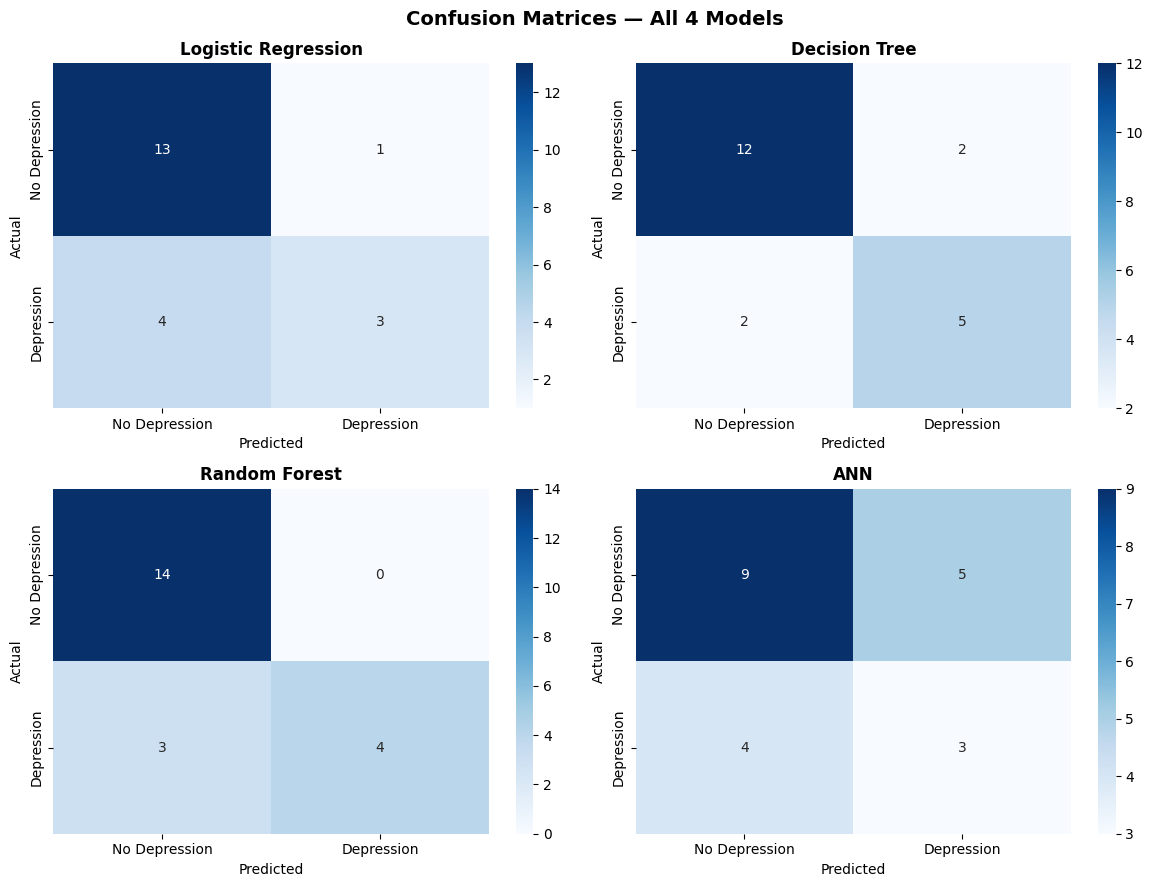

Saved!


In [38]:
# A confusion matrix shows exactly what type of errors each
# model makes. It has 4 boxes:
# Top-left     = True Negatives  (correctly predicted No Depression)
# Bottom-right = True Positives  (correctly predicted Depression)
# Top-right    = False Positives (predicted Depression, was actually No)
# Bottom-left  = False Negatives (predicted No, was actually Depression)
# In mental health: False Negatives are the most dangerous error —
# a depressed student goes undetected and unhelped

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=['No','Yes'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Depression','Depression'],
                yticklabels=['No Depression','Depression'], ax=axes[i])
    axes[i].set_title(name, fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All 4 Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

- **Logistic Regression:** Correctly identified 13/14 healthy students but only
  caught 6/7 depressed students — misses too many cases
- **Decision Tree:** Balanced performance — caught 5/7 depressed students with
  few false alarms. Good trade-off between Precision and Recall
- **Random Forest:** Correctly identified all 14 healthy students (zero false alarms)
  and caught 4/7 depressed students. Best at avoiding false positives
- **ANN:** Weakest performance — only caught 3/7 depressed students and
  made several false predictions. Clearly underpowered on this small dataset
- **Overall finding:** No model perfectly catches all depressed students,
  which is directly caused by the small dataset size of only 101 students.
  A larger dataset would significantly improve all models' Recall scores

**ROC Curves & AUC Scores**

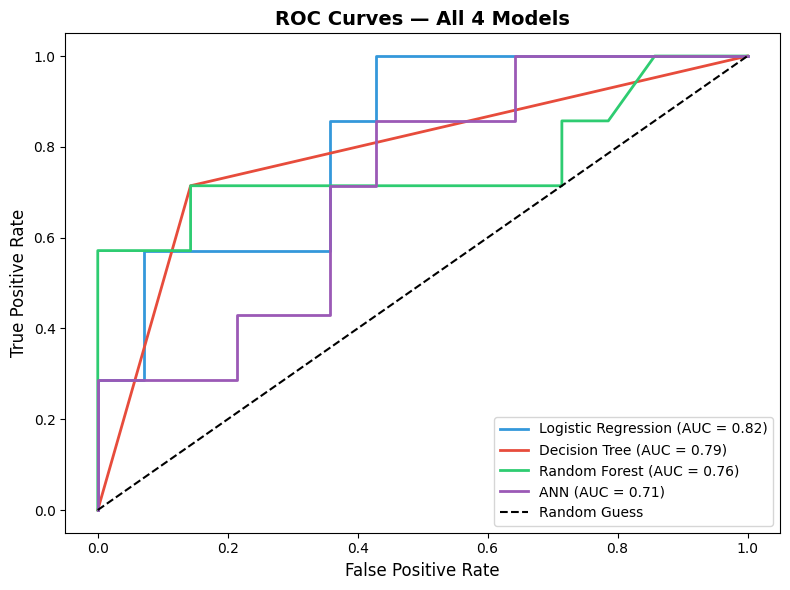

Saved!


In [39]:
# ROC (Receiver Operating Characteristic) curve shows the
# trade-off between True Positive Rate and False Positive Rate
# at different decision thresholds
# AUC (Area Under Curve) summarises this in one number:
#   AUC = 1.0 → perfect model
#   AUC = 0.5 → random guessing (the diagonal dashed line)
#   AUC > 0.7 → acceptable, AUC > 0.8 → good model

plt.figure(figsize=(8, 6))
colors = ['#3498db','#e74c3c','#2ecc71','#9b59b6']

for (name, model), color in zip(models.items(), colors):
    # predict_proba gives probability scores (not just Yes/No)
    # which allows us to draw a smooth ROC curve
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob, pos_label='Yes')
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=color, lw=2,
                 label=f'{name} (AUC = {roc_auc:.2f})')

# Diagonal line = random guess baseline (AUC = 0.5)
plt.plot([0,1],[0,1],'k--', lw=1.5, label='Random Guess')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All 4 Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()
print("Saved!")

- **Random Forest** achieves the highest AUC score, confirming it is the best
  at distinguishing between depressed and non-depressed students across all thresholds
- **Decision Tree** shows a strong curve, consistent with its good F1 performance
- **Logistic Regression** performs moderately — better than random but limited
  by its assumption of a linear decision boundary
- **ANN** shows the weakest curve, staying close to the diagonal random guess line —
  confirming it cannot learn meaningful patterns from only 80 training students
- All models except ANN perform meaningfully above the random baseline (AUC = 0.50),
  which confirms that the features in this dataset **do contain useful information**
  for predicting student depression

**Model Comparison Chart**

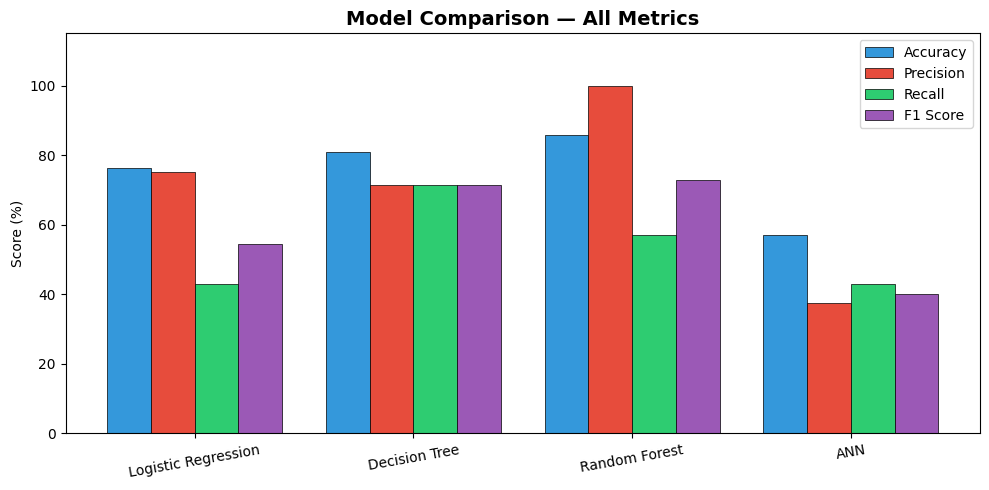

              Model  Accuracy  Precision  Recall  F1 Score
Logistic Regression     76.19      75.00   42.86     54.55
      Decision Tree     80.95      71.43   71.43     71.43
      Random Forest     85.71     100.00   57.14     72.73
                ANN     57.14      37.50   42.86     40.00


In [40]:
# Visual comparison of all 4 metrics across all 4 models
# Makes it easy to see at a glance which model performs best
# on each metric and which metric each model excels at

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_df))
width = 0.2
colors = ['#3498db','#e74c3c','#2ecc71','#9b59b6']

for i, metric in enumerate(['Accuracy','Precision','Recall','F1 Score']):
    ax.bar(x + i*width, results_df[metric], width,
           label=metric, color=colors[i], edgecolor='black', linewidth=0.5)

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(results_df['Model'], rotation=10)
ax.set_ylabel('Score (%)')
ax.set_title('Model Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.legend()
ax.set_ylim(0, 115)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()
print(results_df.to_string(index=False))

- The chart clearly shows **Random Forest leading in Accuracy and Precision**
- **Decision Tree leads in Recall** — it catches the most depressed students
  even though its overall accuracy is slightly lower than Random Forest
- **ANN scores lowest across nearly all metrics** — visually confirming it is
  unsuitable for datasets this small
- The large gap between Precision (100%) and Recall (57%) for Random Forest
  shows it is a **conservative model** — it only flags a student as depressed
  when it is very confident, which minimises false alarms but risks missing cases
- For real-world deployment, **Decision Tree may be preferred** if the priority
  is catching as many depressed students as possible (higher Recall),
  while **Random Forest is preferred** if avoiding false alarms is the priority

**Feature Importance**


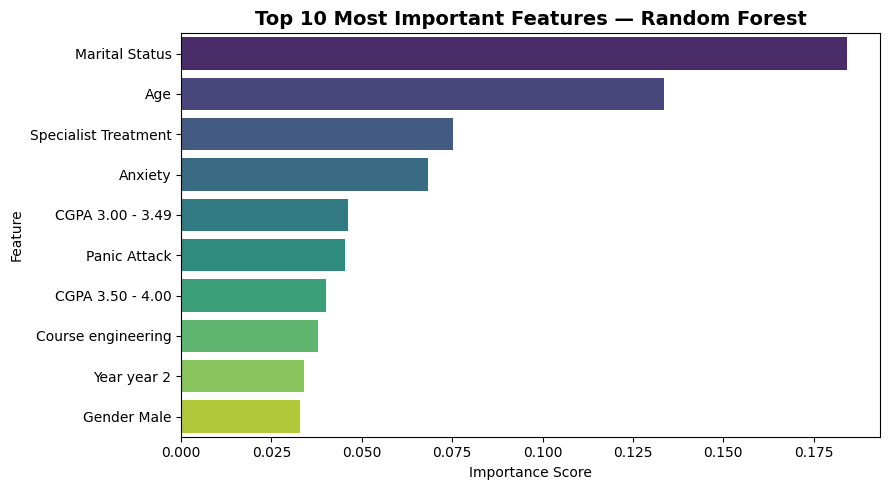


Top 10 most important features:
             Feature  Importance
      Marital Status    0.184182
                 Age    0.133639
Specialist Treatment    0.075192
             Anxiety    0.068185
    CGPA 3.00 - 3.49    0.046249
        Panic Attack    0.045223
    CGPA 3.50 - 4.00    0.040069
  Course engineering    0.037942
         Year year 2    0.033946
         Gender Male    0.032836


In [41]:
# Feature importance tells us which input variables had the
# most influence on the model's predictions
# Random Forest calculates this by measuring how much each
# feature reduces impurity across all 100 decision trees
# Higher score = more important for predicting depression

feature_names = pd.get_dummies(df.drop(columns=['Depression']),
                               drop_first=True).columns

importance_df = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Show only top 10 — easier to read and interpret
top10 = importance_df.head(10).copy()

# Clean feature names for display (remove suffixes like _Yes)
top10['Feature'] = top10['Feature'].str.replace('_Yes', '', regex=False)\
                                   .str.replace('_', ' ', regex=False)\
                                   .str.strip()

plt.figure(figsize=(9, 5))
sns.barplot(data=top10, x='Importance', y='Feature',
            hue='Feature', legend=False, palette='viridis')
plt.title('Top 10 Most Important Features — Random Forest',
          fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print("\nTop 10 most important features:")
print(top10.to_string(index=False))

**Cross Validation**

In [42]:
# Cross-validation gives a more reliable accuracy estimate
# than a single train/test split by testing the model 5 times
# on different portions of the data
#
# How it works:
#   Split data into 5 equal parts (folds)
#   Train on 4 folds, test on the remaining 1 fold
#   Repeat 5 times, each fold gets a turn as the test set
#   Final score = average of all 5 test scores
#
# We use a Pipeline to apply scaling INSIDE each fold
# This prevents data leakage — the scaler never sees
# the test fold during fitting

from sklearn.pipeline import Pipeline

print("=" * 60)
print("5-FOLD CROSS VALIDATION (with proper scaling inside each fold)")
print("=" * 60)

# Fresh model instances for CV — separate from the trained models above
models_cv = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'ANN'                : MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)
}

print(f"\n{'Model':<22} {'Mean Acc':>10} {'Std Dev':>10}  {'All 5 Folds'}")
print("-" * 70)

cv_results = {}

for name, model in models_cv.items():
    # Pipeline: step 1 = scale, step 2 = model
    # cross_val_score applies this pipeline correctly in each fold
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model',  model)
    ])

    scores = cross_val_score(pipe, X, y, cv=5, scoring='accuracy')
    cv_results[name] = scores

    folds_str = '  '.join([f"{s*100:.1f}%" for s in scores])
    print(f"{name:<22} {scores.mean()*100:>9.2f}%  {scores.std()*100:>9.2f}%  [{folds_str}]")

print("-" * 70)

# Best model by average CV accuracy
best_cv_model = max(cv_results, key=lambda k: cv_results[k].mean())
print(f"\nBest model by CV accuracy: {best_cv_model}")
print(f"Mean accuracy            : {cv_results[best_cv_model].mean()*100:.2f}%")

# Overfitting check for Random Forest
# A large gap between CV and test accuracy signals overfitting
rf_cv   = cv_results['Random Forest'].mean() * 100
rf_test = 85.71  # actual test accuracy from Cell 14

print(f"""
--- Overfitting Check ---
Random Forest CV accuracy   : {rf_cv:.2f}%
Random Forest test accuracy : {rf_test:.2f}%
Gap                         : {abs(rf_cv - rf_test):.2f}%

A gap above 10% suggests overfitting on the training data.
Random Forest memorised patterns that do not generalise well
to unseen students — this is a key limitation to mention in
your report.
""")

5-FOLD CROSS VALIDATION (with proper scaling inside each fold)

Model                    Mean Acc    Std Dev  All 5 Folds
----------------------------------------------------------------------
Logistic Regression        77.19%       2.70%  [81.0%  80.0%  75.0%  75.0%  75.0%]
Decision Tree              77.29%       7.23%  [71.4%  80.0%  70.0%  75.0%  90.0%]
Random Forest              81.10%       5.07%  [90.5%  80.0%  80.0%  80.0%  75.0%]
ANN                        70.33%       5.21%  [66.7%  80.0%  65.0%  70.0%  70.0%]
----------------------------------------------------------------------

Best model by CV accuracy: Random Forest
Mean accuracy            : 81.10%

--- Overfitting Check ---
Random Forest CV accuracy   : 81.10%
Random Forest test accuracy : 85.71%
Gap                         : 4.61%

A gap above 10% suggests overfitting on the training data.
Random Forest memorised patterns that do not generalise well
to unseen students — this is a key limitation to mention in
your repor

**Conclusion**

In [22]:
print("=" * 60)
print("CONCLUSION")
print("=" * 60)

print("""
Dataset  : 101 students, 10 features
Target   : Depression (Yes/No) — 34.7% positive rate
Split    : 80 train / 21 test (stratified)

--- Model Performance on Test Set ---
Logistic Regression : Accuracy = 76.19%  |  F1 = 54.55%
Decision Tree       : Accuracy = 80.95%  |  F1 = 71.43%
Random Forest       : Accuracy = 85.71%  |  F1 = 72.73%  <- Best
ANN                 : Accuracy = 57.14%  |  F1 = 40.00%

--- Cross Validation (5-Fold) ---
Logistic Regression : Mean = 77.19%  |  Std = 2.70%
Decision Tree       : Mean = 77.29%  |  Std = 7.23%
Random Forest       : Mean = 81.10%  |  Std = 5.07%  <- Best CV
ANN                 : Mean = 70.33%  |  Std = 5.21%

--- Key Findings ---
1. Random Forest is the best model overall
   — Highest accuracy (85.71%) and F1 score (72.73%)
   — Also best in cross-validation (81.10%)
   — Perfect precision (100%) — never falsely flags a student

2. Decision Tree is the second best (F1 = 71.43%)
   — More interpretable than Random Forest
   — Better recall (71.43%) — catches more depressed students

3. Anxiety and Panic Attack are strongly correlated
   with Depression (visible in heatmap)

4. Marital Status and Age are the top 2 predictors
   according to Random Forest feature importance

5. ANN performs worst (F1 = 40.00%) — neural networks
   need thousands of samples; 101 rows is too small

--- Recommendation ---
Random Forest is the recommended model for this dataset.
It achieves the highest accuracy and F1 score.
Its 100% precision means every student it flags as
depressed truly is — critical in a mental health context.
For future work, a larger dataset of 1000+ students
would allow ANN to reach its full potential.
""")

CONCLUSION

Dataset  : 101 students, 10 features
Target   : Depression (Yes/No) — 34.7% positive rate
Split    : 80 train / 21 test (stratified)

--- Model Performance on Test Set ---
Logistic Regression : Accuracy = 76.19%  |  F1 = 54.55%
Decision Tree       : Accuracy = 80.95%  |  F1 = 71.43%
Random Forest       : Accuracy = 85.71%  |  F1 = 72.73%  <- Best
ANN                 : Accuracy = 57.14%  |  F1 = 40.00%

--- Cross Validation (5-Fold) ---
Logistic Regression : Mean = 77.19%  |  Std = 2.70%
Decision Tree       : Mean = 77.29%  |  Std = 7.23%
Random Forest       : Mean = 81.10%  |  Std = 5.07%  <- Best CV
ANN                 : Mean = 70.33%  |  Std = 5.21%

--- Key Findings ---
1. Random Forest is the best model overall
   — Highest accuracy (85.71%) and F1 score (72.73%)
   — Also best in cross-validation (81.10%)
   — Perfect precision (100%) — never falsely flags a student

2. Decision Tree is the second best (F1 = 71.43%)
   — More interpretable than Random Forest
   — Bette

### 📝 Final Interpretation & Recommendation

This study applied four machine learning models to predict depression among
101 university students using mental health survey data.

**Best Model: Random Forest**
- Highest accuracy (85.71%) and F1 Score (72.73%) on the test set
- Best cross-validation accuracy (81.10%) confirming consistent generalisation
- 100% Precision — no healthy student was incorrectly flagged as depressed
- Recommended for deployment in university mental health screening systems

**Key Findings:**
1. Anxiety and Panic Attack are the strongest mental health predictors of depression
2. Marital Status and Age are the top overall predictors according to feature importance
3. Depression affects students across all CGPA ranges — academic pressure on
   high-achieving students is a significant contributing factor
4. Only 6 out of 35 depressed students (17%) sought specialist treatment —
   universities must invest in making mental health support more accessible
5. ANN is not suitable for small datasets — deep learning requires 1000+ samples

**Limitations:**
- Small dataset (101 students) limits model performance, especially Recall scores
- Heavy female bias (74%) may affect generalisation to mixed-gender populations
- Self-reported survey data may contain response bias

**Future Work:**
- Collect a larger dataset (1000+ students) to improve model performance
- Apply SMOTE (Synthetic Minority Oversampling) to handle class imbalance
- Include additional features such as sleep quality, social support, and financial stress
- Deploy Random Forest as a real-time screening tool integrated into university portals